# Hypothesis 7: useful performance exists across target dimensions

We sweep target dimensions on a doubling grid from 8 through 1024 and compare accuracy, output storage, and serialized model size. The grid intentionally goes beyond the 120 original input features. A useful plateau means a smaller dimension is within two percentage points of the best observed accuracy.

In [1]:
import sys
import pickle
from pathlib import Path
notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists(): notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))
import matplotlib.pyplot as plt
import pandas as pd
from _hypothesis_utils import classification_data, classification_score, downstream_classifier, forest_sketch

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 128).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 256).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 512).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 1024).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 128).The dimensionality of the problem will not be reduced.
  warnings.warn(


...

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 128).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 256).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 512).The dimensionality of the problem will not be reduced.
  warnings.warn(


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/random_projection.py:411: DataDimensionalityWarning: The number of components is higher than the number of features: n_features < n_components (120 < 1024).The dimensionality of the problem will not be reduced.
  warnings.warn(


,mean_accuracy,std_accuracy,mean_output_mb,mean_model_mb
dimension,,,,
8,0.592,0.026,0.081,2.794
16,0.640,0.029,0.161,3.878
32,0.660,0.015,0.322,6.241
64,0.732,0.024,0.645,9.917
128,0.728,0.018,1.289,17.059
256,0.770,0.020,2.578,30.302
512,0.807,0.010,5.156,56.273
1024,0.841,0.012,10.312,102.101


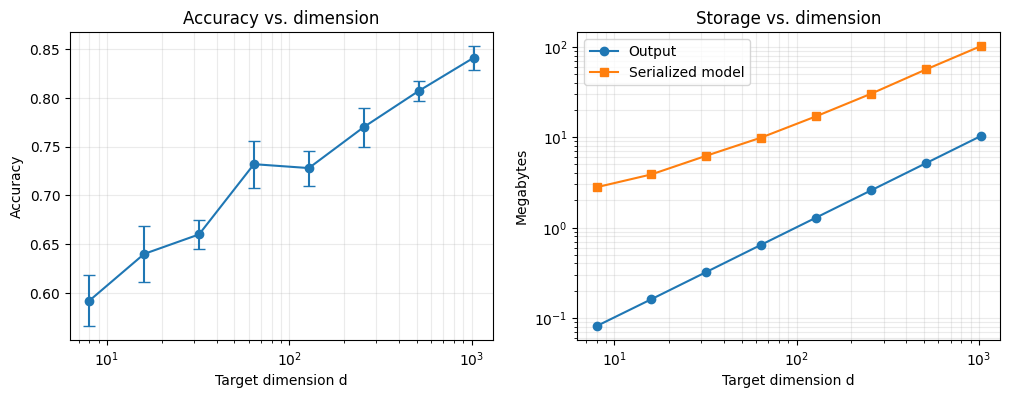

Hypothesis 7: NOT SUPPORTED — smallest dimension within 0.02 of best=1024


In [2]:
DATA_SEED = 42
EXPERIMENT_SEEDS = [0, 1, 2, 3]
X_train, _, X_test, y_train, _, y_test = classification_data(DATA_SEED)
rows = []
for seed in EXPERIMENT_SEEDS:
    for dimension in [8, 16, 32, 64, 128, 256, 512, 1024]:
        representation = forest_sketch(seed, dimension, 2)
        X_train_view = representation.fit_transform(X_train, y_train)
        X_test_view = representation.transform(X_test)
        accuracy, errors = classification_score(downstream_classifier(seed), X_train_view, y_train, X_test_view, y_test)
        rows.append({'seed': seed, 'dimension': dimension, 'accuracy': accuracy, 'errors': errors, 'output_mb': X_train_view.nbytes / 2**20, 'model_mb': len(pickle.dumps(representation, protocol=pickle.HIGHEST_PROTOCOL)) / 2**20})
results = pd.DataFrame(rows)
summary = results.groupby('dimension').agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'), mean_output_mb=('output_mb', 'mean'), mean_model_mb=('model_mb', 'mean')).round(3)
display(summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summary.index, summary.mean_accuracy, yerr=summary.std_accuracy, marker='o', capsize=4)
axes[0].set(xscale='log', xlabel='Target dimension d', ylabel='Accuracy', title='Accuracy vs. dimension')
axes[1].plot(summary.index, summary.mean_output_mb, marker='o', label='Output')
axes[1].plot(summary.index, summary.mean_model_mb, marker='s', label='Serialized model')
axes[1].set(xscale='log', yscale='log', xlabel='Target dimension d', ylabel='Megabytes', title='Storage vs. dimension')
axes[1].legend()
for axis in axes: axis.grid(alpha=0.25, which='both')
plt.show()
best = summary.mean_accuracy.max()
smallest_near_best = summary[summary.mean_accuracy >= best - 0.02].index.min()
supported = smallest_near_best < summary.index.max()
print(f'Hypothesis 7: {"SUPPORTED" if supported else "NOT SUPPORTED"} — smallest dimension within 0.02 of best={smallest_near_best}')

## Conclusion

**Hypothesis:** there is a useful target-dimension plateau substantially smaller than the uncompressed path representation.

**Experiment:** sweep `d` over 8, 16, 32, 64, 128, 256, 512, and 1024 across four paired seeds on one fixed 120-feature split, with two Forest Sketch iterations and a fixed downstream classifier.

**Measure:** held-out accuracy and integer errors, output storage, and serialized model size. A plateau is defined as within 0.02 of the best observed accuracy.

**Result:** in this executed run accuracy increased from 0.592 at d=8 to 0.841 at d=1024, and the smallest dimension within 0.02 of the best was d=1024. There is no observed saturation by 1024; dimensions above the 120 original input features are valid, but the larger representations also increase storage and model size substantially.